In [1]:
import pandas as pd
from datasets_cfg import *
from utils import *

/home/shulab/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [8]:

std_names = ['subject_id','gender','age']

def standardize_columns(df, tgtlabels):
    """
    将 tgtlabels 对应的列重命名为标准名称
    
    Parameters:
        df: 输入 DataFrame
        tgtlabels: 包含前三个元素依次对应 subject_id, age, sex 的列表
    
    Returns:
        重命名后的 DataFrame
    """
    # 创建映射：原列名 → 标准列名
    rename_map = {}
    for i, std_name in enumerate(std_names):
        if i < len(tgtlabels) and tgtlabels[i] in df.columns:
            rename_map[tgtlabels[i]] = std_name
    
    print(f"重命名映射: {rename_map}")
    
    # 重命名
    df_renamed = df.rename(columns=rename_map)
    df_renamed['gender'] = df_renamed['gender'].replace(['F', 2], 'Female')
    df_renamed['gender'] = df_renamed['gender'].replace(['M', 1], 'Male')
    
    # 检查哪些标准列缺失
    missing = set(std_names) - set(rename_map.values())
    if missing:
        print(f"警告: 缺少列 {missing}")
    
    return df_renamed

def load_data_and_to_long(df,tgt_labels):
    df_long = df.melt(
        id_vars=std_names,  # 保持不变的列
        value_vars=tgt_labels,                            # 需要转换的列
        var_name='intell_category',                       # 新列名：原列名
        value_name='scores'                         # 新列名：原值
    )
    df_long['scores'] = pd.to_numeric(df_long['scores'], errors="coerce")
    df_long = df_long[df_long['scores']<500]
    return df_long

main

正在处理数据集: HCD
重命名映射: {'src_subject_id': 'subject_id', 'sex': 'gender', 'interview_age': 'age'}
['scores']


findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsof

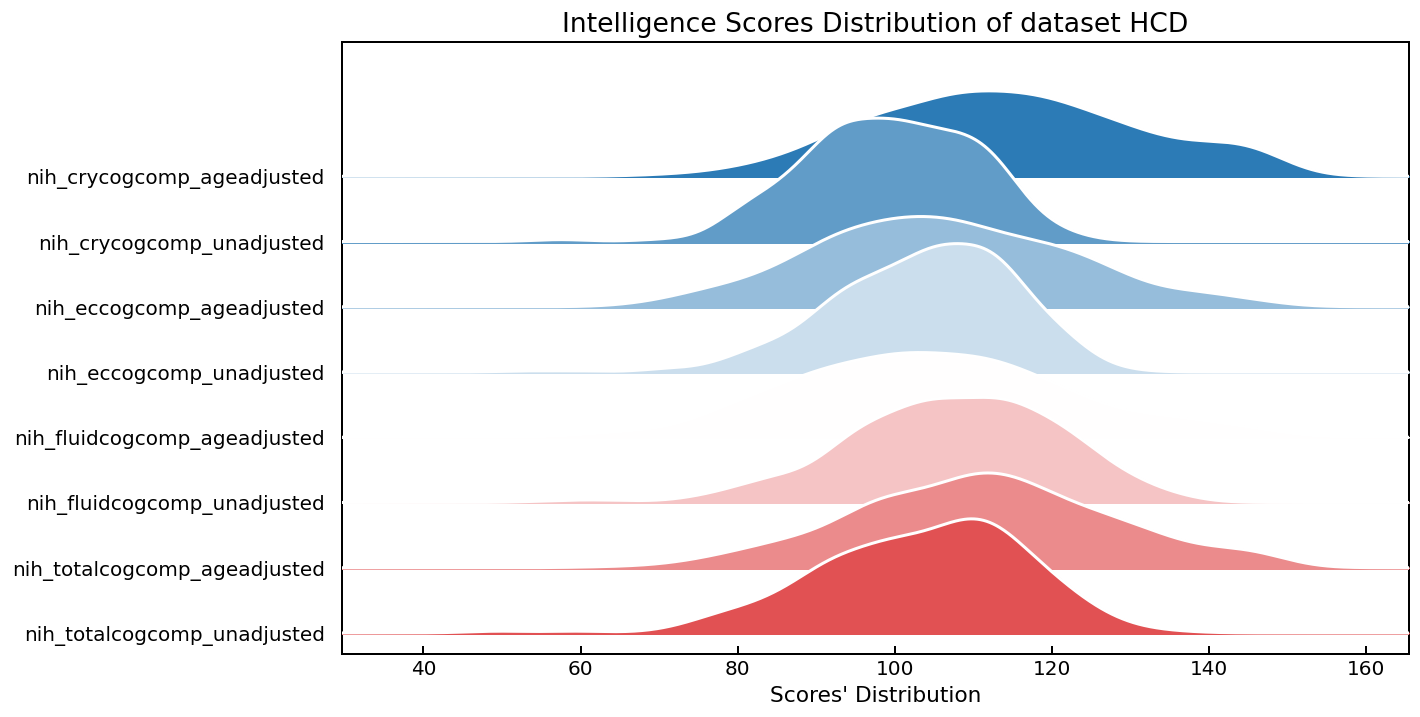

findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'Microsof

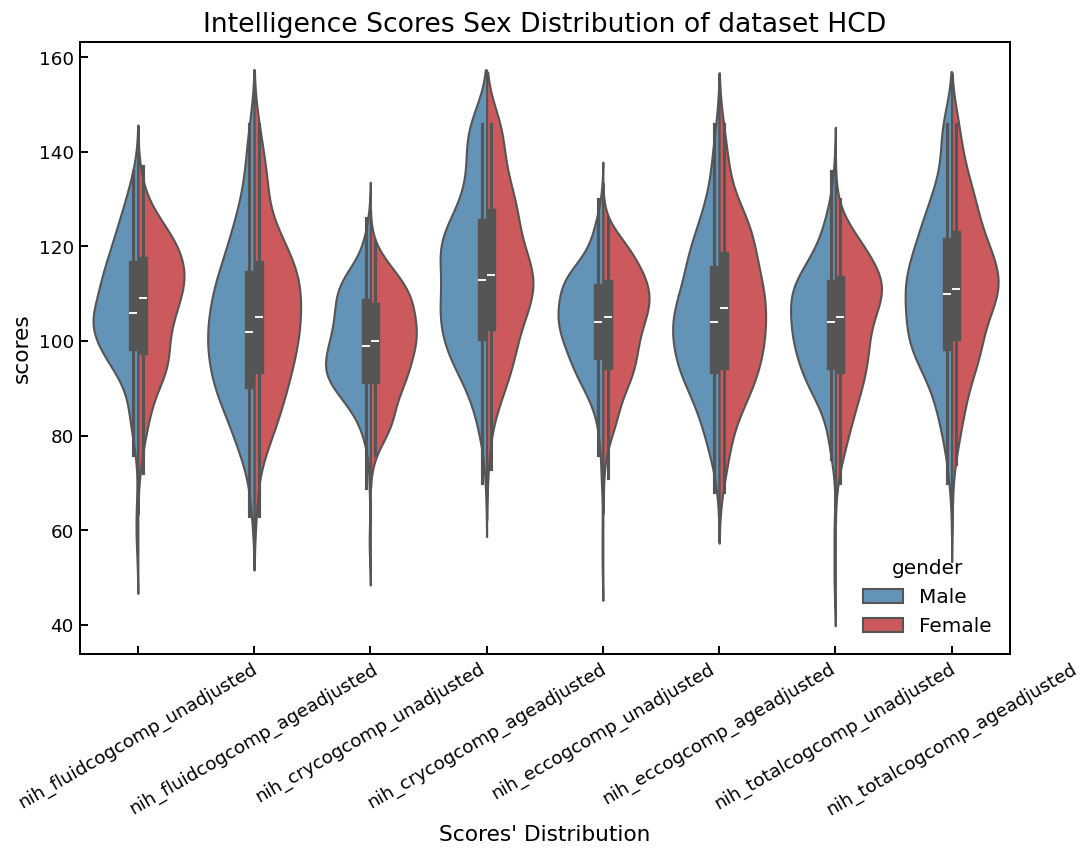

In [ ]:
for dataset in ["HCD"]:
    print(f"正在处理数据集: {dataset}")
    cfg = datasets[dataset]
    df = pd.read_csv(cfg["scores_path"])
    df_std = standardize_columns(df, cfg["tgt_label_list"])
    if dataset == "ABCD":
        df_std = df_std[df_std['gender'] != 3]
    df_long = load_data_and_to_long(df_std, cfg["tgt_label_list"][3:])
    labellist = cfg["tgt_label_list"][3:]
    
    draw_ridge_distrib(df_long=df_long, 
                       dataset_type=dataset, 
                       res_dir=f"../pics/data_distribution")
    draw_violin_distrib(df_long=df_long,
                        dataset_type=dataset,
                        labellist=cfg["tgt_label_list"][3:],
                        res_dir=f"../pics/data_distribution")